In [86]:
# Gerekli kütüphaneleri içe aktarır.

import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [87]:
# Sonuçların tekrar üretilebilir olması için rastgelelik değerlerini sabitler.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [88]:
# data.csv dosyasını okur ve ilk satırları gösterir.

df = pd.read_csv("data.csv")

print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [89]:
# Özellikleri X, hedef değişkeni y olarak ayırır.

X = df.drop("target", axis=1)
y = df["target"]

print("X:", X.shape)
print("y:", y.shape)

X: (569, 30)
y: (569,)


In [90]:
# Veriyi train, validation ve test olarak ayrı ayrı ve sınıf oranlarını koruyarak böler.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (364, 30)
Validation: (91, 30)
Test: (114, 30)


In [91]:
# StandardScaler'ı yalnızca training verisinde öğrenir ve validation/test verisine uygular.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [92]:
# Küçük tabular veri için dropout içeren, dengeli kapasiteli binary classification ağı oluşturur.

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.15),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.10),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# Modelin optimizer, loss fonksiyonu ve başarı metriğini belirler.

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

In [94]:
# Validation loss düzelmediğinde öğrenme hızını azaltır ve gerekirse eğitimi erken durdurur.

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=0.00001
)

In [95]:
# Modeli ayrı validation setiyle eğitir ve en iyi ağırlıkları korur.

history = model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=10,
    batch_size=16,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7967 - loss: 0.5380 - val_accuracy: 0.9341 - val_loss: 0.4074 - learning_rate: 0.0010
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9341 - loss: 0.3299 - val_accuracy: 0.9341 - val_loss: 0.2572 - learning_rate: 0.0010
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9505 - loss: 0.2105 - val_accuracy: 0.9451 - val_loss: 0.1805 - learning_rate: 0.0010
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9588 - loss: 0.1517 - val_accuracy: 0.9560 - val_loss: 0.1451 - learning_rate: 0.0010
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9615 - loss: 0.1166 - val_accuracy: 0.9670 - val_loss: 0.1244 - learning_rate: 0.0010
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9753 - loss: 0.1174 - val_accuracy: 0.9670 - val_loss: 0.1087 - learning_rate: 0.0010
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9725 - loss: 0.0866 - val_accu

In [96]:
# Eğitilmiş modeli test verisi üzerinde değerlendirir.

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.0951
Test Accuracy: 0.9474


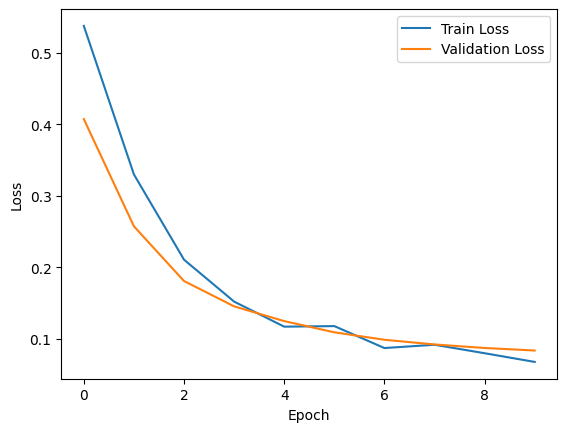

In [97]:
# Eğitim ve validation loss değerlerinin epoch boyunca değişimini çizer.

import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

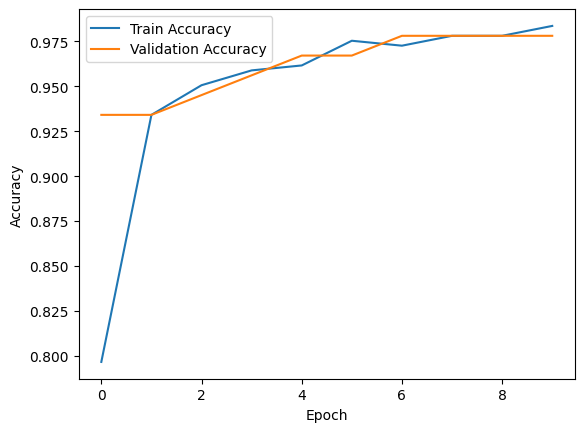

In [98]:
# Eğitim ve validation accuracy değerlerinin epoch boyunca değişimini çizer.

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [99]:
# Test verisi için olasılık tahminlerini üretir ve 0.5 eşik değeriyle sınıfa çevirir.

y_prob = model.predict(X_test)

y_pred = (y_prob >= 0.5).astype(int).ravel()

print(y_pred[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[0 1 0 0 0 1 1 0 0 0]


In [100]:
# Confusion matrix ile doğru ve yanlış sınıflandırmaları gösterir.

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40  2]
 [ 4 68]]


In [101]:
# Precision, recall, F1-score ve accuracy değerlerini ayrıntılı olarak gösterir.

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.91      0.95      0.93        42
      Benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [102]:
# ROC-AUC skorunu hesaplayarak modelin sınıfları ayırma gücünü ölçer.

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob.ravel())

print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.994
